In [1]:
import pandas as pd

df = pd.read_csv("../data/poll_data.csv")

df.head()

,Timestamp,Age Group,Gender,Preferred Tool,Satisfaction (1-5),Feedback
0,2024-04-01 10:00:00,18-24,Male,Python,5,Very useful and easy
1,2024-04-01 10:10:00,25-34,Female,Excel,4,Helpful for analysis
2,2024-04-01 10:20:00,18-24,Female,Python,5,Excellent features
3,2024-04-01 10:30:00,35-44,Male,R,3,Needs improvement
4,2024-04-01 10:40:00,25-34,Male,Python,4,Good for visualization


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Timestamp           10 non-null     object
 1   Age Group           10 non-null     object
 2   Gender              10 non-null     object
 3   Preferred Tool      10 non-null     object
 4   Satisfaction (1-5)  10 non-null     int64 
 5   Feedback            10 non-null     object
dtypes: int64(1), object(5)
memory usage: 612.0+ bytes


In [4]:
#basic stats 
df.describe()

,Satisfaction (1-5)
count,10.000000
mean,4.200000
std,0.788811
min,3.000000
25%,4.000000
50%,4.000000
75%,5.000000
max,5.000000


In [5]:
#missing values
df.isnull().sum()

Timestamp             0
Age Group             0
Gender                0
Preferred Tool        0
Satisfaction (1-5)    0
Feedback              0
dtype: int64

In [6]:
#unique preffered tools
df["Preferred Tool"].unique()

array(['Python', 'Excel', 'R'], dtype=object)

In [7]:
df["Satisfaction (1-5)"].unique()

array([5, 4, 3])

In [8]:
#removeing dublicated
df = df.drop_duplicates()

print("Duplicates removed successfully")

Duplicates removed successfully


In [9]:
#handle missing values
df = df.dropna()

print("Missing values removed successfully")

Missing values removed successfully


In [10]:
df["Preferred Tool"] = df["Preferred Tool"].str.strip().str.title()

df["Preferred Tool"].unique()

array(['Python', 'Excel', 'R'], dtype=object)

In [11]:
#convert timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df["Timestamp"].head()

0   2024-04-01 10:00:00
1   2024-04-01 10:10:00
2   2024-04-01 10:20:00
3   2024-04-01 10:30:00
4   2024-04-01 10:40:00
Name: Timestamp, dtype: datetime64[ns]

In [12]:
#ensure satisfation is numeric 
df["Satisfaction (1-5)"] = pd.to_numeric(df["Satisfaction (1-5)"])

df["Satisfaction (1-5)"].dtype

dtype('int64')

In [13]:
#create date column
df["Date"] = df["Timestamp"].dt.date

df.head()

,Timestamp,Age Group,Gender,Preferred Tool,Satisfaction (1-5),Feedback,Date
0,2024-04-01 10:00:00,18-24,Male,Python,5,Very useful and easy,2024-04-01
1,2024-04-01 10:10:00,25-34,Female,Excel,4,Helpful for analysis,2024-04-01
2,2024-04-01 10:20:00,18-24,Female,Python,5,Excellent features,2024-04-01
3,2024-04-01 10:30:00,35-44,Male,R,3,Needs improvement,2024-04-01
4,2024-04-01 10:40:00,25-34,Male,Python,4,Good for visualization,2024-04-01


In [14]:
#create feedback length column 
df["Feedback Length"] = df["Feedback"].astype(str).apply(len)

df[["Feedback", "Feedback Length"]].head()

,Feedback,Feedback Length
0,Very useful and easy,20
1,Helpful for analysis,20
2,Excellent features,18
3,Needs improvement,17
4,Good for visualization,22


In [15]:
#save cleaned data 
df.to_csv("../data/cleaned_poll_data.csv", index=False)

print("Cleaned data saved successfully")

Cleaned data saved successfully


## eda and visualisation 

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\admin\AppData\Local\Temp\ipykernel_10516\2343308879.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Preferred Tool", data=df, palette="Set2")


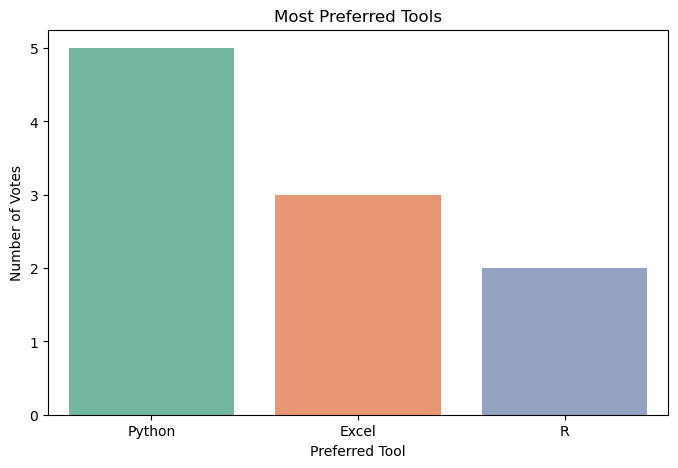

In [20]:
#bar graph for prefered tools vote
plt.figure(figsize=(8,5))

sns.countplot(x="Preferred Tool", data=df, palette="Set2")

plt.title("Most Preferred Tools")
plt.xlabel("Preferred Tool")
plt.ylabel("Number of Votes")

plt.show()

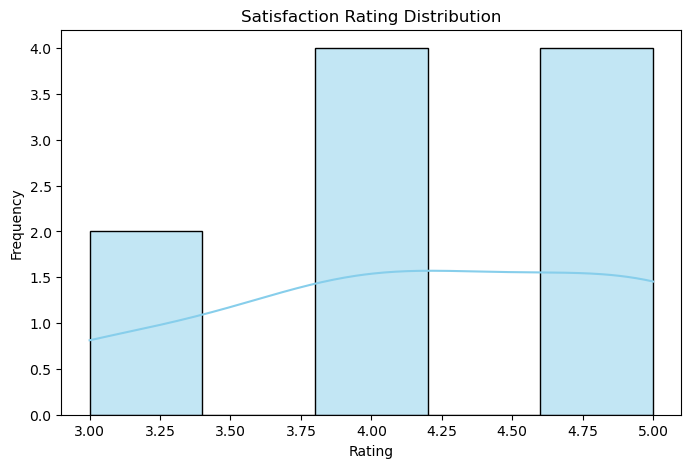

In [21]:
#histogram:satisfactory rating 
plt.figure(figsize=(8,5))

sns.histplot(df["Satisfaction (1-5)"], bins=5, kde=True, color="skyblue")

plt.title("Satisfaction Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()


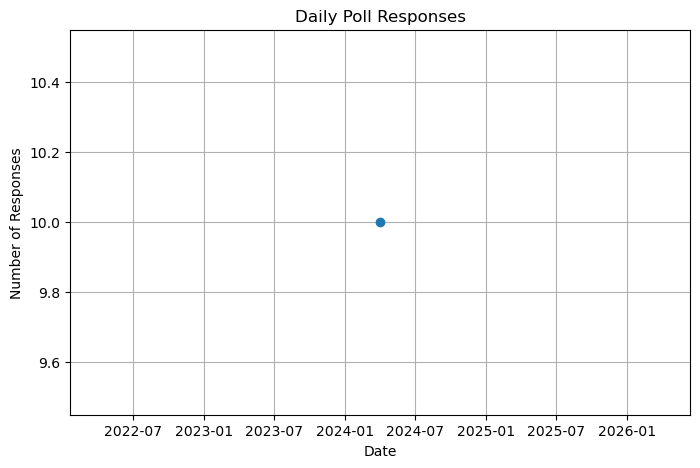

In [23]:
daily = df.groupby("Date").size()

plt.figure(figsize=(8,5))

daily.plot(kind="line", marker="o")

plt.title("Daily Poll Responses")
plt.xlabel("Date")
plt.ylabel("Number of Responses")

plt.grid(True)
plt.show()

In [25]:
!pip install wordcloud

In [26]:
#for feedback analysis 
from wordcloud import WordCloud

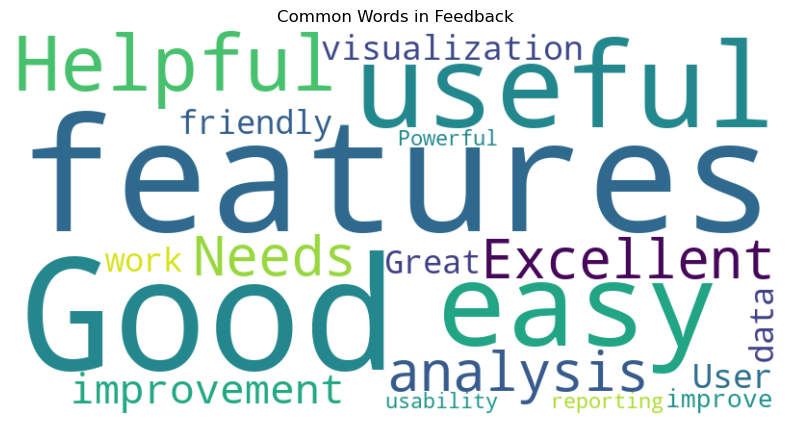

In [27]:
text = " ".join(df["Feedback"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Feedback")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_10516\2766380646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


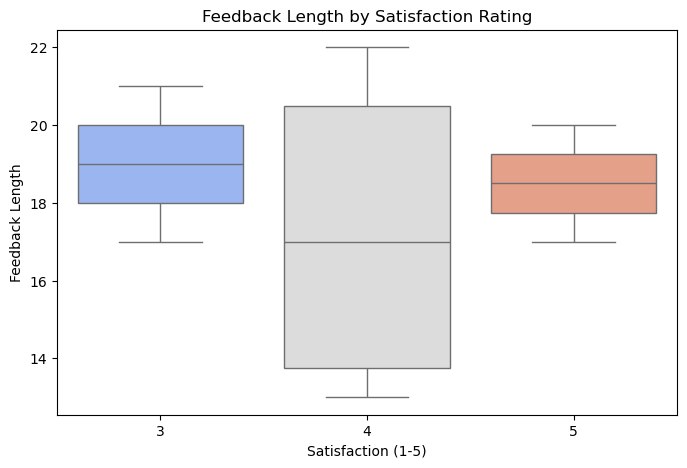

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Satisfaction (1-5)",
    y="Feedback Length",
    data=df,
    palette="coolwarm"
)

plt.title("Feedback Length by Satisfaction Rating")

plt.show()

In [30]:
total_responses = len(df)
print("Total Responses:", total_responses)

most_preferred = df["Preferred Tool"].value_counts().idxmax()
print("Most Preferred Tool:", most_preferred)

avg_satisfaction = df["Satisfaction (1-5)"].mean()
print("Average Satisfaction:", round(avg_satisfaction, 2))

tool_satisfaction = df.groupby("Preferred Tool")["Satisfaction (1-5)"].mean()
print(tool_satisfaction)

highest_rated_tool = tool_satisfaction.idxmax()
print("Highest Rated Tool:", highest_rated_tool)



Total Responses: 10
Most Preferred Tool: Python
Average Satisfaction: 4.2
Preferred Tool
Excel     4.0
Python    4.8
R         3.0
Name: Satisfaction (1-5), dtype: float64
Highest Rated Tool: Python


In [31]:
print(f"Total Responses: {total_responses}")
print(f"Most Preferred Tool: {most_preferred}")
print(f"Average Satisfaction Rating: {round(avg_satisfaction,2)}")
print(f"Highest Rated Tool: {highest_rated_tool}")

Total Responses: 10
Most Preferred Tool: Python
Average Satisfaction Rating: 4.2
Highest Rated Tool: Python
